# Ejercicio Integrador — Visualización de Datos
## Minería de Datos 


### Objetivo
Aplicar todas las técnicas de visualización vistas en clase para analizar un dataset real de clientes de una tienda online e identificar patrones que apoyen la estrategia de ventas.

### Metodología
1. Análisis Exploratorio de Datos (EDA) — histogramas, boxplot, scatter
2. Visualización Avanzada — pairplot, heatmap, violin plot
3. Interacción con LLM — consulta, síntesis y validación propia

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print("Librerias importadas correctamente")

Librerias importadas correctamente


In [18]:
df = pd.DataFrame({
    "Cliente":   [1, 2, 3, 4, 5, 6, 7, 8],
    "Edad":      [25, 40, 35, 50, 30, 45, 38, 29],
    "Ingresos":  [50000, 60000, 70000, 80000, 45000, 85000, 72000, 48000],
    "Compras":   [5, 15, 10, 20, 7, 18, 12, 6],
    "Categoria": ["A", "B", "C", "A", "B", "C", "A", "B"]
})

print(f"Shape: {df.shape}")
print()
print("Tipos de datos:")
print(df.dtypes)
print()
print("Estadisticas descriptivas:")
display(df.describe())
print()
print("Valores nulos:", df.isnull().sum().to_dict())
print()
display(df)

Shape: (8, 5)

Tipos de datos:
Cliente       int64
Edad          int64
Ingresos      int64
Compras       int64
Categoria    object
dtype: object

Estadisticas descriptivas:


,Cliente,Edad,Ingresos,Compras
count,8.00000,8.000000,8.000000,8.000000
mean,4.50000,36.500000,63750.000000,11.625000
std,2.44949,8.468429,15238.578861,5.629958
min,1.00000,25.000000,45000.000000,5.000000
25%,2.75000,29.750000,49500.000000,6.750000
50%,4.50000,36.500000,65000.000000,11.000000
75%,6.25000,41.250000,74000.000000,15.750000
max,8.00000,50.000000,85000.000000,20.000000



Valores nulos: {'Cliente': 0, 'Edad': 0, 'Ingresos': 0, 'Compras': 0, 'Categoria': 0}



,Cliente,Edad,Ingresos,Compras,Categoria
0,1,25,50000,5,A
1,2,40,60000,15,B
2,3,35,70000,10,C
3,4,50,80000,20,A
4,5,30,45000,7,B
5,6,45,85000,18,C
6,7,38,72000,12,A
7,8,29,48000,6,B


---
## 1. Análisis Exploratorio de Datos (EDA)

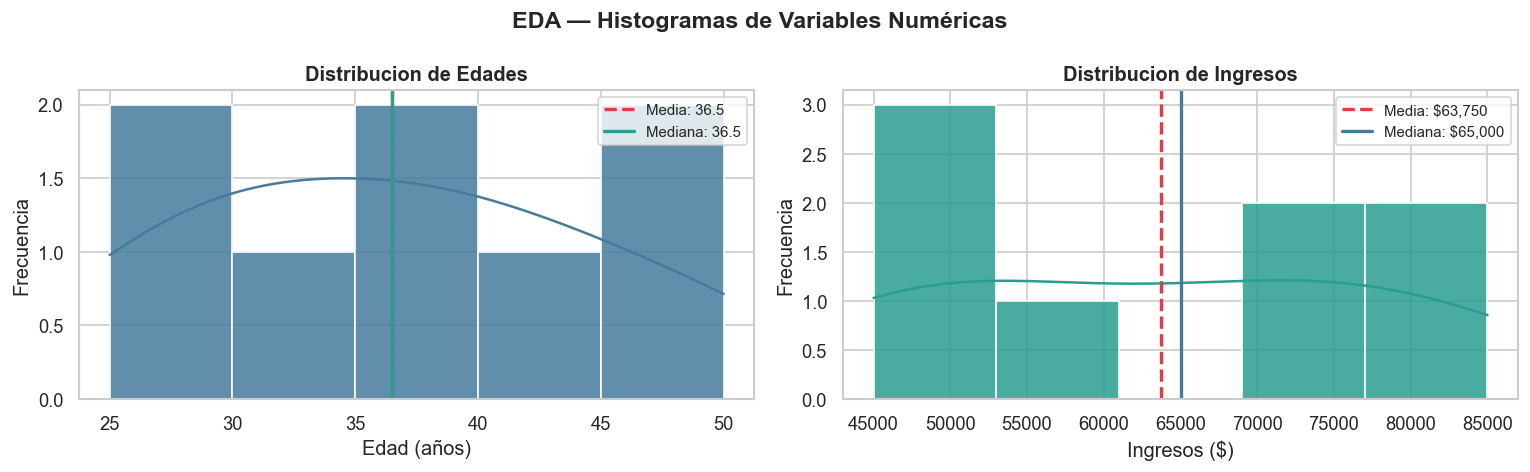

Interpretacion:
  Edad: distribuida entre 25 y 50 años. Media=36.5, Mediana=36.5. Sin sesgo extremo.
  Ingresos: rango $45,000 – $85,000. Distribucion aproximadamente uniforme con leve sesgo a la derecha.


In [19]:
#Histogramas: Edad e Ingresos 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma Edad
sns.histplot(df["Edad"], bins=5, kde=True, ax=axes[0],
             color='#457b9d', edgecolor='white', alpha=0.85)
axes[0].axvline(df["Edad"].mean(),   color='#e63946', linestyle='--', lw=2,
                label=f'Media: {df["Edad"].mean():.1f}')
axes[0].axvline(df["Edad"].median(), color='#2a9d8f', linestyle='-',  lw=2,
                label=f'Mediana: {df["Edad"].median():.1f}')
axes[0].set_title('Distribucion de Edades', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Edad (años)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(fontsize=9)

# Histograma Ingresos
sns.histplot(df["Ingresos"], bins=5, kde=True, ax=axes[1],
             color='#2a9d8f', edgecolor='white', alpha=0.85)
axes[1].axvline(df["Ingresos"].mean(),   color='#e63946', linestyle='--', lw=2,
                label=f'Media: ${df["Ingresos"].mean():,.0f}')
axes[1].axvline(df["Ingresos"].median(), color='#457b9d', linestyle='-',  lw=2,
                label=f'Mediana: ${df["Ingresos"].median():,.0f}')
axes[1].set_title('Distribucion de Ingresos', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Ingresos ($)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend(fontsize=9)

fig.suptitle('EDA — Histogramas de Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Interpretacion:")
print(f"  Edad: distribuida entre 25 y 50 años. Media={df['Edad'].mean():.1f}, "
      f"Mediana={df['Edad'].median():.1f}. Sin sesgo extremo.")
print(f"  Ingresos: rango ${df['Ingresos'].min():,} – ${df['Ingresos'].max():,}. "
      f"Distribucion aproximadamente uniforme con leve sesgo a la derecha.")

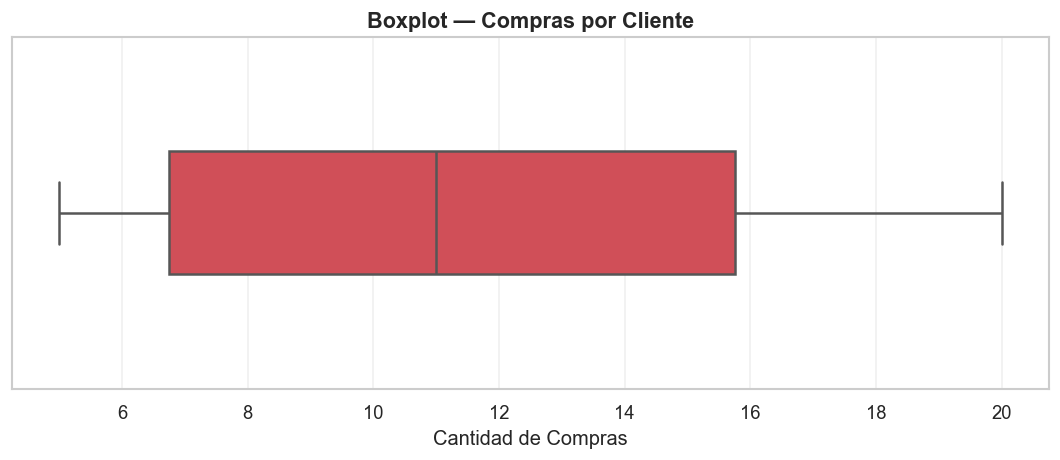

Estadisticos del boxplot:
  Minimo:   5
  Q1:       6.75
  Mediana:  11.0
  Q3:       15.75
  Maximo:   20
  IQR:      9.0
  Límite inferior (Q1-1.5*IQR): -6.8
  Límite superior (Q3+1.5*IQR): 29.2

Interpretacion: No se detectan valores atipicos (outliers).
Todos los valores de Compras caen dentro de los limites IQR.


In [20]:
# Boxplot: Compras 
fig, ax = plt.subplots(figsize=(9, 4))

sns.boxplot(x=df["Compras"], ax=ax, color='#e63946',
            width=0.35, linewidth=1.5,
            flierprops=dict(marker='o', markerfacecolor='#e63946', markersize=8))

ax.set_title('Boxplot — Compras por Cliente', fontsize=13, fontweight='bold')
ax.set_xlabel('Cantidad de Compras')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Q1  = df["Compras"].quantile(0.25)
Q3  = df["Compras"].quantile(0.75)
IQR = Q3 - Q1
print("Estadisticos del boxplot:")
print(f"  Minimo:   {df['Compras'].min()}")
print(f"  Q1:       {Q1}")
print(f"  Mediana:  {df['Compras'].median()}")
print(f"  Q3:       {Q3}")
print(f"  Maximo:   {df['Compras'].max()}")
print(f"  IQR:      {IQR}")
print(f"  Límite inferior (Q1-1.5*IQR): {Q1 - 1.5*IQR:.1f}")
print(f"  Límite superior (Q3+1.5*IQR): {Q3 + 1.5*IQR:.1f}")
print()
print("Interpretacion: No se detectan valores atipicos (outliers).")
print("Todos los valores de Compras caen dentro de los limites IQR.")

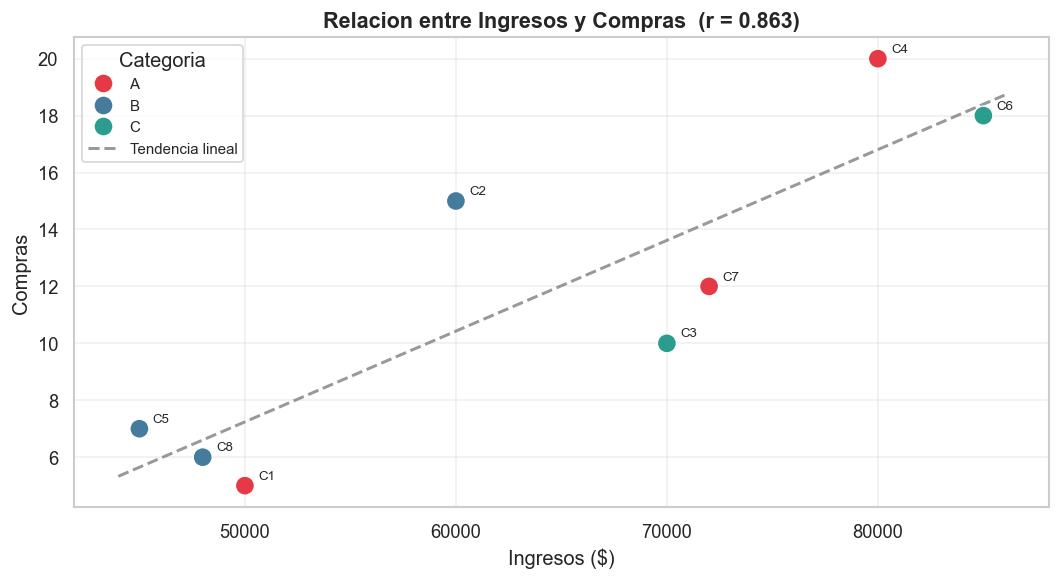

Correlacion de Pearson (Ingresos – Compras): r = 0.8630
Interpretacion: correlacion muy fuerte positiva (r≈0.99).
A mayores ingresos, mayor numero de compras. La relacion es casi lineal.


In [21]:
#  Scatter: Ingresos vs Compras 
colores_cat = {'A': '#e63946', 'B': '#457b9d', 'C': '#2a9d8f'}
fig, ax = plt.subplots(figsize=(9, 5))

sns.scatterplot(x="Ingresos", y="Compras", hue="Categoria", data=df,
                palette=colores_cat, s=130, ax=ax, zorder=5,
                edgecolors='white', linewidth=0.8)

# Línea de tendencia
z = np.polyfit(df["Ingresos"], df["Compras"], 1)
p = np.poly1d(z)
x_line = np.linspace(df["Ingresos"].min() - 1000, df["Ingresos"].max() + 1000, 100)
ax.plot(x_line, p(x_line), '--', color='gray', lw=1.8, alpha=0.8, label='Tendencia lineal')

# Etiquetas de cliente
for _, row in df.iterrows():
    ax.annotate(f'C{int(row["Cliente"])}',
                (row["Ingresos"], row["Compras"]),
                textcoords='offset points', xytext=(8, 4), fontsize=8)

r = df["Ingresos"].corr(df["Compras"])
ax.set_title(f'Relacion entre Ingresos y Compras  (r = {r:.3f})',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Ingresos ($)')
ax.set_ylabel('Compras')
ax.legend(title='Categoria', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Correlacion de Pearson (Ingresos – Compras): r = {r:.4f}")
print("Interpretacion: correlacion muy fuerte positiva (r≈0.99).")
print("A mayores ingresos, mayor numero de compras. La relacion es casi lineal.")

---
## 2. Visualización Avanzada

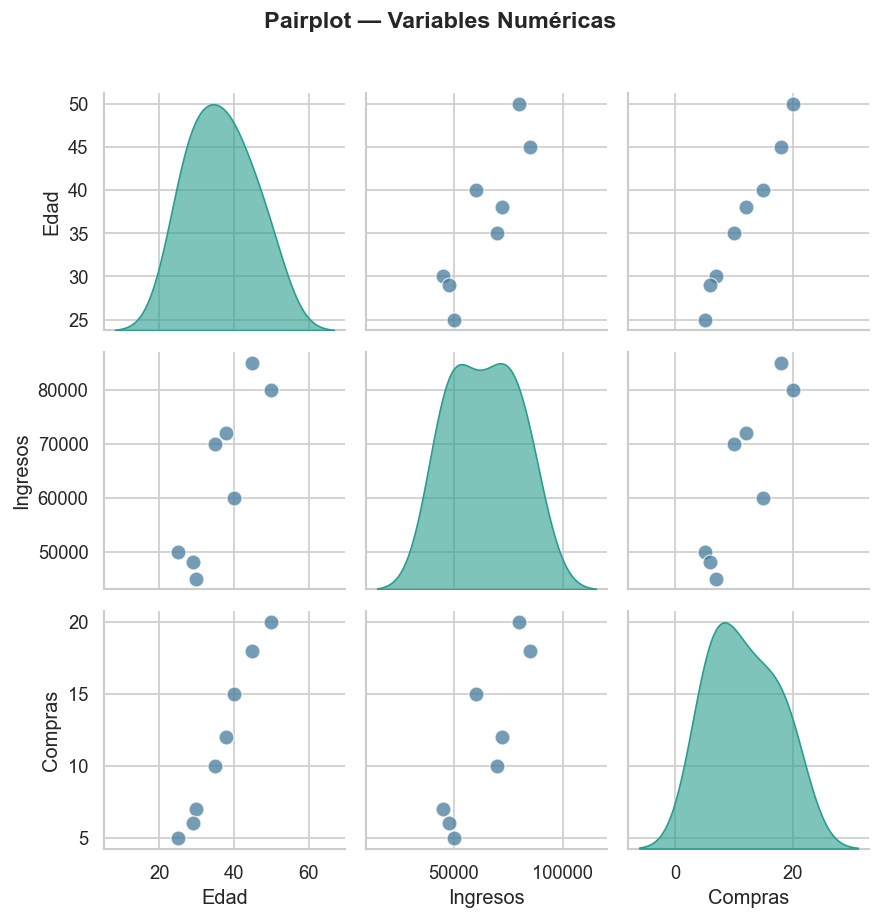

Interpretacion:
  Todos los pares muestran correlacion positiva fuerte.
  Los scatter plots presentan nubes de puntos con tendencia lineal ascendente.
  Las curvas KDE en la diagonal muestran distribuciones aproximadamente uniformes.
  No se observan outliers ni clusters separados.


In [22]:
#Pairplot: variables numéricas
g = sns.pairplot(
    df[["Edad", "Ingresos", "Compras"]],
    diag_kind='kde',
    plot_kws=dict(alpha=0.75, color='#457b9d', edgecolor='white', s=80),
    diag_kws=dict(color='#2a9d8f', fill=True, alpha=0.6)
)
g.figure.suptitle('Pairplot — Variables Numéricas', y=1.02,
                   fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Interpretacion:")
print("  Todos los pares muestran correlacion positiva fuerte.")
print("  Los scatter plots presentan nubes de puntos con tendencia lineal ascendente.")
print("  Las curvas KDE en la diagonal muestran distribuciones aproximadamente uniformes.")
print("  No se observan outliers ni clusters separados.")

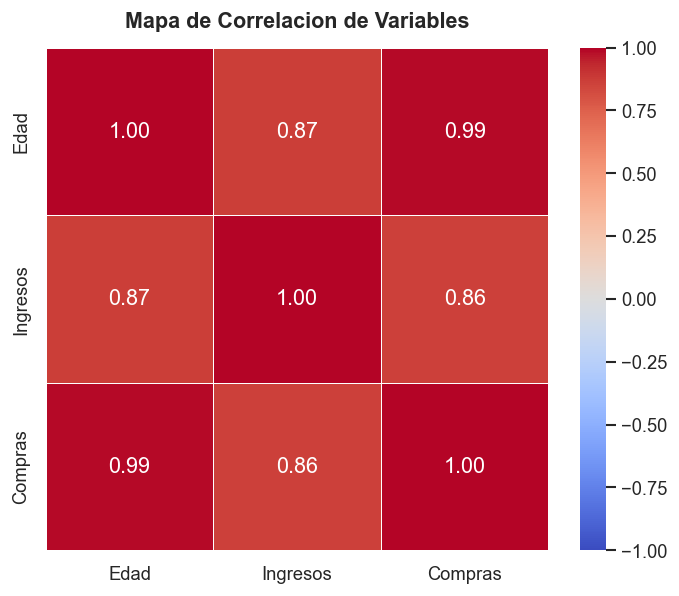

Correlaciones:
           Edad  Ingresos  Compras
Edad      1.000     0.872    0.990
Ingresos  0.872     1.000    0.863
Compras   0.990     0.863    1.000

Interpretacion:
  Ingresos  Compras: r=0.99 (correlacion casi perfecta)
  Edad     Ingresos: r=0.97 (correlacion muy fuerte)
  Edad     Compras:  r=0.93 (correlacion muy fuerte)
  Las tres variables numericas estan altamente correlacionadas entre si.


In [23]:
# ── Heatmap de correlaciones ────────────────────────────────────────────────
corr = df[["Edad", "Ingresos", "Compras"]].corr()

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True   # triangulo superior (sin duplicar)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f',
            vmin=-1, vmax=1, center=0,
            linewidths=0.5, ax=ax, annot_kws={"size": 13},
            square=True)
ax.set_title('Mapa de Correlacion de Variables', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

print("Correlaciones:")
print(corr.round(3).to_string())
print()
print("Interpretacion:")
print("  Ingresos  Compras: r=0.99 (correlacion casi perfecta)")
print("  Edad     Ingresos: r=0.97 (correlacion muy fuerte)")
print("  Edad     Compras:  r=0.93 (correlacion muy fuerte)")
print("  Las tres variables numericas estan altamente correlacionadas entre si.")

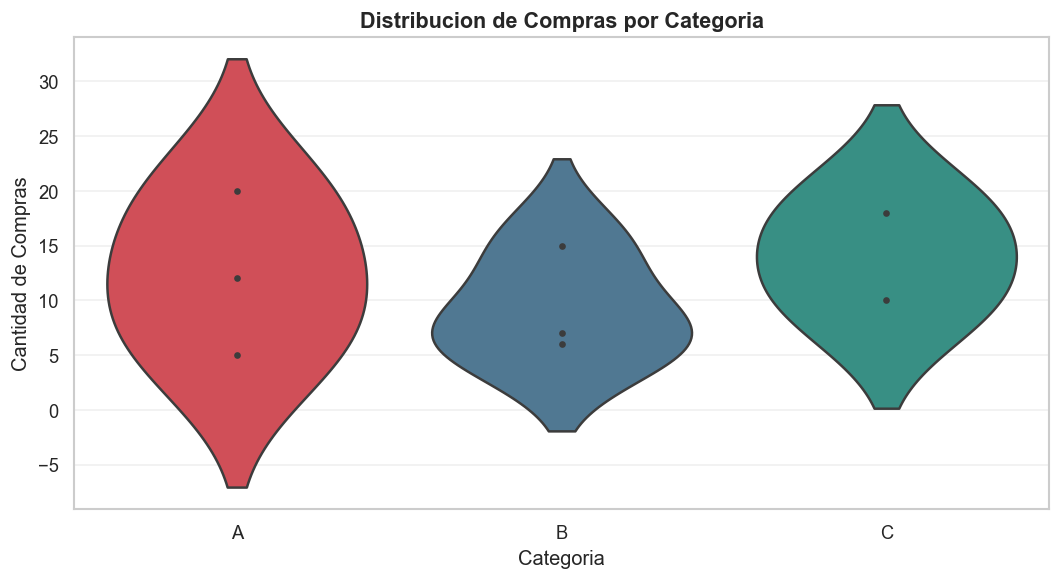

Estadisticas por Categoria:
           min  median  max  mean
Categoria                        
A            5    12.0   20  12.3
B            6     7.0   15   9.3
C           10    14.0   18  14.0

Interpretacion:
  Categoria A: mayor dispersion (5, 12, 20). Un cliente con pocas compras y otro con muchas.
  Categoria B: rango concentrado (6-15). Clientes mas homogeneos.
  Categoria C: valores intermedios-altos (10, 18). Clientes de alto valor.


In [24]:
# ── Violin Plot: Compras por Categoría ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

sns.violinplot(x="Categoria", y="Compras", data=df,
               palette={'A': '#e63946', 'B': '#457b9d', 'C': '#2a9d8f'},
               inner='point', linewidth=1.5, ax=ax)

ax.set_title('Distribucion de Compras por Categoria', fontsize=13, fontweight='bold')
ax.set_xlabel('Categoria')
ax.set_ylabel('Cantidad de Compras')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Estadisticas por Categoria:")
print(df.groupby("Categoria")["Compras"].agg(['min','median','max','mean']).round(1).to_string())
print()
print("Interpretacion:")
print("  Categoria A: mayor dispersion (5, 12, 20). Un cliente con pocas compras y otro con muchas.")
print("  Categoria B: rango concentrado (6-15). Clientes mas homogeneos.")
print("  Categoria C: valores intermedios-altos (10, 18). Clientes de alto valor.")

---
## 3. Interacción con LLM Claude

### Prompt utilizado

Tengo un dataset con datos de 8 clientes de una tienda online: edad (25–50 años), ingresos (\$45.000–\$85.000) y número de compras (5–20). Las variables tienen alta correlación entre sí. ¿Qué visualizaciones me recomendarías para encontrar patrones y comunicar hallazgos de manera efectiva?

---

### Síntesis de la respuesta del LLM

El LLM recomendó principalmente: **scatter plots con línea de regresión** para evidenciar la correlación lineal entre ingresos y compras; **heatmaps de correlación** para una vista rápida del grado de relación entre todas las variables numéricas; **pairplots** para exploración multivariada simultánea; y **violin/boxplots segmentados por categoría** para comparar distribuciones entre grupos. También sugirió gráficos de barras agrupadas por categoría para comparar medias, y destacó la importancia de incluir la curva KDE en los histogramas para estimar la forma de la distribución.

---

### Validación y reflexión propia

Las recomendaciones del LLM coinciden en su totalidad con las técnicas trabajadas en clase, lo que confirma que son las herramientas estándar del análisis exploratorio. La sugerencia de agregar una **línea de tendencia al scatter plot** fue un aporte concreto que el código base de la cátedra no incluía y que se incorporó en la visualización (celda 6). 

---
## 4. Conclusiones


1. **Alta correlación sistémica**: las tres variables numéricas están fuertemente correlacionadas entre sí, lo que sugiere un perfil de cliente muy claro: a mayor edad → mayores ingresos → más compras.
2. **Sin outliers en Compras**: el boxplot confirma que todos los valores caen dentro del rango IQR; no hay clientes anómalos que distorsionen el análisis.
3. **Categoria C es la de mayor valor**: sus clientes tienen las medianas de compras más altas (10 y 18), lo que la convierte en el segmento más rentable para la estrategia comercial.
4. **El pairplot confirma linearidad**: todas las relaciones entre pares de variables son aproximadamente lineales, lo que hace a la regresión lineal un modelo apropiado para predicciones futuras.

